# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [24]:
ROLL_NO = 1024160122
NAME = "Riya Gupta"

import nltk

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)

assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [25]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [26]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [27]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160122   Name: Riya Gupta   Fingerprint: 96429134   Tickets: 14

Ticket_ID                                                                                      Ticket_Text
      T01                                   The printer keeps asking for login. Is there another solution?
      T02           Printer stopped responding after restarting the system. The same problem occurs again.
      T03                                        The VPN was working yesterday. I don't know what changed.
      T04 I keep getting logged out of the server after resetting my password. I have tried several times!
      T05                                                                   Error code 0x80070005 appears.
      T06                             I can't open the server on my laptop. The same problem occurs again.
      T07                                                                    The LMS says 'Not Submitted'.
      T08                                                     

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [28]:
# Run process_ticket() on every ticket
processed = {}

for _, row in df.iterrows():
    processed[row["Ticket_ID"]] = process_ticket(row["Ticket_Text"])


# Create one row for every ticket
q1_rows = []

for ticket_id, result in processed.items():

    q1_rows.append({
        "Ticket_ID": ticket_id,
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation Tokens": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique Tokens": len(set(result["tokens"])),
        "Final Tokens": len(result["final"])
    })


q1_table = pd.DataFrame(q1_rows)

total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation Tokens": q1_table["Punctuation Tokens"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique Tokens": len(
        set(
            token
            for result in processed.values()
            for token in result["tokens"]
        )
    ),
    "Final Tokens": q1_table["Final Tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)

print("Q1 — Preprocessing Statistics")
display(q1_table)


selected_id = FOCUS[0]

selected_text = df.loc[
    df["Ticket_ID"] == selected_id,
    "Ticket_Text"
].iloc[0]

selected = processed[selected_id]

print("\n" + "="*70)
print("SELECTED TICKET")
print("="*70)

print("\nTicket ID:")
print(selected_id)

print("\nRaw Ticket:")
print(selected_text)

print("\nActual Tokens:")
print(selected["tokens"])

print("\nPunctuation Tokens:")
print(selected["punct"])

print("\nStopwords:")
print(selected["stops"])

print("\nFinal Tokens:")
print(selected["final"])



non_word_tokens = sorted(
    set(
        token
        for result in processed.values()
        for token in result["final"]
        if token in {
            "n't", "'s", "'m", "'re",
            "'ve", "'d", "'ll",
            "ca", "wo"
        }
    )
)

print("\n" + "="*70)
print("OBSERVATION")
print("="*70)

print("Non-word-looking final tokens found:")
print(non_word_tokens)

print("""
These tokens come mainly from contractions.

For example:
    can't  -> ca + n't
    couldn't -> could + n't
    it's -> it + 's
    don't -> do + n't

The official process_ticket() uses NLTK word_tokenize(),
which splits contractions into separate tokens. Stopword
removal does not join those pieces back together.
""")

Q1 — Preprocessing Statistics


,Ticket_ID,Sentences,Tokens,Punctuation Tokens,Stopwords,Unique Tokens,Final Tokens
0,T01,2,12,2,4,12,6
1,T02,2,14,2,5,12,7
2,T03,2,13,2,5,12,6
3,T04,2,19,2,8,18,9
4,T05,1,5,1,0,5,4
5,T06,2,16,2,7,14,7
6,T07,1,7,2,1,7,4
7,T08,2,8,2,1,7,5
8,T09,1,7,2,1,7,4
9,T10,2,15,2,6,13,7



SELECTED TICKET

Ticket ID:
T03

Raw Ticket:
The VPN was working yesterday. I don't know what changed.

Actual Tokens:
['the', 'vpn', 'was', 'working', 'yesterday', '.', 'i', 'do', "n't", 'know', 'what', 'changed', '.']

Punctuation Tokens:
['.', '.']

Stopwords:
['the', 'was', 'i', 'do', 'what']

Final Tokens:
['vpn', 'working', 'yesterday', "n't", 'know', 'changed']

OBSERVATION
Non-word-looking final tokens found:
['ca', "n't", 'wo']

These tokens come mainly from contractions.

For example:
    can't  -> ca + n't
    couldn't -> could + n't
    it's -> it + 's
    don't -> do + n't

The official process_ticket() uses NLTK word_tokenize(),
which splits contractions into separate tokens. Stopword
removal does not join those pieces back together.



**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [29]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]


import re


# Combine all generated tickets
all_ticket_text = "\n".join(df["Ticket_Text"].tolist())


# ============================================
# 1. WORDS LONGER THAN 5 LETTERS
# ============================================

long_word_pattern = r"\b[A-Za-z]{6,}\b"

long_words = re.findall(
    long_word_pattern,
    all_ticket_text
)

print("="*70)
print("WORDS LONGER THAN 5 LETTERS")
print("="*70)
print(long_words)


# ============================================
# 2. NUMBERS
# ============================================
#
# Handles:
# 95.5
# 2.0.1
# 3.12
# 5.30
# 1,250
# 0x80070005
# 99
#
# Version numbers such as 2.0.1 remain one match.

number_pattern = (
    r"(?<![\w.])"
    r"(?:"
    r"0x[0-9A-Fa-f]+"
    r"|"
    r"\d[\d,]*(?:\.\d+)*"
    r")"
    r"(?![\w.])"
)

numbers = re.findall(
    number_pattern,
    all_ticket_text
)

print("\n" + "="*70)
print("NUMBERS")
print("="*70)
print(numbers)


# ============================================
# 3. CAPITALIZED WORDS
# ============================================

capitalized_pattern = r"\b[A-Z][A-Za-z]*\b"

capitalized_words = re.findall(
    capitalized_pattern,
    all_ticket_text
)

print("\n" + "="*70)
print("CAPITALIZED WORDS")
print("="*70)
print(capitalized_words)


# ============================================
# 4. WORDS BEGINNING WITH A VOWEL
# ============================================

vowel_pattern = r"\b[AEIOUaeiou][A-Za-z]*\b"

vowel_words = re.findall(
    vowel_pattern,
    all_ticket_text
)

print("\n" + "="*70)
print("WORDS BEGINNING WITH A VOWEL")
print("="*70)
print(vowel_words)


# ============================================
# EMAIL / URL / PHONE PATTERNS
# ============================================

email_pattern = (
    r"\b[A-Za-z0-9.!#$%&'*+/=?^_`{|}~-]+"
    r"@"
    r"[A-Za-z0-9-]+"
    r"(?:\.[A-Za-z0-9-]+)+\b"
)


url_pattern = (
    r"https?://[^\s<>\"']+"
    r"|"
    r"(?<![@\w])www\.[^\s<>\"']+"
)


phone_pattern = (
    r"(?<!\w)"
    r"(?:"
    r"\+\d{1,3}[\s-]?"
    r"\d{3,5}[\s-]\d{3,5}"
    r"(?:[\s-]\d{3,5})?"
    r"|"
    r"\d{3,5}[\s-]\d{3,5}(?:[\s-]\d{3,5})?"
    r"|"
    r"\d{10}"
    r")"
    r"(?!\w)"
)


# ============================================
# REPLACEMENT FUNCTION
# ============================================

def replace_identifiers(text):

    # URL first
    text = re.sub(
        url_pattern,
        "<URL>",
        text
    )

    # Email
    text = re.sub(
        email_pattern,
        "<EMAIL>",
        text
    )

    # Phone
    text = re.sub(
        phone_pattern,
        "<PHONE>",
        text
    )

    return text


# ============================================
# TEST_LINES
# ============================================

print("\n" + "="*70)
print("REPLACEMENT ON TEST_LINES")
print("="*70)

for i, line in enumerate(TEST_LINES, 1):

    print(f"\nTEST LINE {i}")
    print("Original:")
    print(line)

    print("Replaced:")
    print(replace_identifiers(line))


# ============================================
# REPLACEMENT ON GENERATED TICKETS
# ============================================

print("\n" + "="*70)
print("REPLACEMENT ON GENERATED TICKETS")
print("="*70)

for _, row in df.iterrows():

    print("\n" + row["Ticket_ID"])
    print(replace_identifiers(row["Ticket_Text"]))


print("\n" + "="*70)
print("REGEX VERIFICATION ON TEST_LINES")
print("="*70)

for i, line in enumerate(TEST_LINES, 1):

    print(f"\nLine {i}")

    print("Emails:")
    print(re.findall(email_pattern, line))

    print("URLs:")
    print(re.findall(url_pattern, line))

    print("Phones:")
    print(re.findall(phone_pattern, line))

    print("Numbers:")
    print(re.findall(number_pattern, line))

WORDS LONGER THAN 5 LETTERS
['printer', 'asking', 'another', 'solution', 'Printer', 'stopped', 'responding', 'restarting', 'system', 'problem', 'occurs', 'working', 'yesterday', 'changed', 'getting', 'logged', 'server', 'resetting', 'password', 'several', 'appears', 'server', 'laptop', 'problem', 'occurs', 'Submitted', 'disconnecting', 'Please', 'thapar', 'details', 'unable', 'password', 'latest', 'update', 'Please', 'student', 'portal', 'crashes', 'opening', 'worked', 'yesterday', 'MATLAB', 'working', 'urgent', 'locked', 'laptop', 'Please', 'resolve', 'printer', 'jammed']

NUMBERS
['0x80070005']

CAPITALIZED WORDS
['The', 'Is', 'Printer', 'The', 'The', 'VPN', 'I', 'I', 'I', 'Error', 'I', 'The', 'The', 'LMS', 'Not', 'Submitted', 'The', 'Please', 'See', 'I', 'Please', 'The', 'It', 'The', 'MATLAB', 'This', 'I', 'WiFi', 'Please', 'The']

WORDS BEGINNING WITH A VOWEL
['asking', 'Is', 'another', 'after', 'occurs', 'again', 'I', 'I', 'out', 'of', 'after', 'I', 'Error', 'appears', 'I', 'open'

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [30]:
# ============================================
# Q3. CUSTOM TOKENIZATION
# ============================================

from nltk.tokenize import RegexpTokenizer


# One RegexpTokenizer pattern.
#
# Order is important:
# 1. URLs
# 2. Email addresses
# 3. Phone numbers
# 4. Decimals / versions
# 5. Hyphenated words
# 6. Contractions
# 7. Normal words
# 8. Numbers

TOKEN_PATTERN = r"""
https?://[^\s<>"']+
|
www\.[^\s<>"']+
|
[A-Za-z0-9.!#$%&'*+/=?^_`{|}~-]+@[A-Za-z0-9-]+(?:\.[A-Za-z0-9-]+)+
|
\+\d{1,3}[\s-]?\d{3,5}[\s-]\d{3,5}(?:[\s-]\d{3,5})?
|
\d{3,5}[\s-]\d{3,5}(?:[\s-]\d{3,5})?
|
\d{10}
|
\d+(?:\.\d+)+
|
[A-Za-z]+(?:-[A-Za-z]+)+
|
[A-Za-z]+(?:n't|'[A-Za-z]+)
|
[A-Za-z]+
|
\d+(?:,\d+)*
"""


# Remove whitespace from verbose regex
TOKEN_PATTERN = re.sub(
    r"\s+",
    "",
    TOKEN_PATTERN
)


custom_tokenizer = RegexpTokenizer(
    TOKEN_PATTERN,
    flags=re.IGNORECASE
)


def my_tokenize(text):

    return custom_tokenizer.tokenize(text)


# ============================================
# TEST_LINES
# ============================================

print("="*70)
print("CUSTOM TOKENIZER — TEST_LINES")
print("="*70)

for i, line in enumerate(TEST_LINES, 1):

    print(f"\nLine {i}")
    print(my_tokenize(line))


# ============================================
# COMPARE WITH WORD_TOKENIZE
# ============================================

print("\n" + "="*70)
print("TEST_LINES — word_tokenize vs my_tokenize")
print("="*70)

for i, line in enumerate(TEST_LINES, 1):

    nltk_tokens = word_tokenize(line)
    custom_tokens = my_tokenize(line)

    print(f"\nLine {i}")

    print("word_tokenize:")
    print(nltk_tokens)

    print("\nmy_tokenize:")
    print(custom_tokens)


# ============================================
# COMPARE ALL GENERATED TICKETS
# ============================================

comparison_rows = []

for _, row in df.iterrows():

    nltk_tokens = word_tokenize(
        row["Ticket_Text"]
    )

    custom_tokens = my_tokenize(
        row["Ticket_Text"]
    )

    comparison_rows.append({
        "Ticket_ID": row["Ticket_ID"],
        "word_tokenize": nltk_tokens,
        "my_tokenize": custom_tokens,
        "Different": nltk_tokens != custom_tokens
    })


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n" + "="*70)
print("TICKET COMPARISON")
print("="*70)

display(
    comparison_df[
        ["Ticket_ID", "Different"]
    ]
)

different_count = int(
    comparison_df["Different"].sum()
)

print(
    f"\nTickets tokenized differently: "
    f"{different_count} out of {len(df)}"
)


# ============================================
# SHOW ACTUAL DIFFERENCES
# ============================================

print("\n" + "="*70)
print("EXAMPLES OF DIFFERENCES")
print("="*70)

shown = 0

for _, row in df.iterrows():

    wt = word_tokenize(
        row["Ticket_Text"]
    )

    mt = my_tokenize(
        row["Ticket_Text"]
    )

    if wt != mt:

        print("\nTicket:", row["Ticket_ID"])

        print("Original:")
        print(row["Ticket_Text"])

        print("\nword_tokenize:")
        print(wt)

        print("\nmy_tokenize:")
        print(mt)

        shown += 1

        if shown == 5:
            break


print("""
Main differences:

1. Contractions:
   word_tokenize() splits "isn't" into "is" and "n't",
   while my_tokenize() keeps "isn't" together.

2. Hyphenated words:
   word_tokenize() separates "Wi-Fi" and
   "state-of-the-art", while my_tokenize() keeps them
   as single tokens.

3. URLs and email addresses:
   word_tokenize() can split punctuation inside these
   structures, while my_tokenize() preserves them.

4. Decimals and versions:
   my_tokenize() preserves values such as 95.5 and
   2.0.1 as single tokens.

5. Phone numbers:
   my_tokenize() keeps phone numbers together.
""")

CUSTOM TOKENIZER — TEST_LINES

Line 1
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

Line 2
['Call', '+91 98765 43210', '+91-98765-43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5', 'done', 'fee', 'Rs', '1,250']

Line 3
['The', 'state-of-the-art', 'lab', "isn't", 'open', 'log-in', 'at', '5.30', 'p', 'm', "didn't", 'work']

TEST_LINES — word_tokenize vs my_tokenize

Line 1
word_tokenize:
['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

my_tokenize:
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

Line 2
word_tokenize:
['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

my_t

,Ticket_ID,Different
0,T01,True
1,T02,True
2,T03,True
3,T04,True
4,T05,True
5,T06,True
6,T07,True
7,T08,True
8,T09,True
9,T10,True



Tickets tokenized differently: 14 out of 14

EXAMPLES OF DIFFERENCES

Ticket: T01
Original:
The printer keeps asking for login. Is there another solution?

word_tokenize:
['The', 'printer', 'keeps', 'asking', 'for', 'login', '.', 'Is', 'there', 'another', 'solution', '?']

my_tokenize:
['The', 'printer', 'keeps', 'asking', 'for', 'login', 'Is', 'there', 'another', 'solution']

Ticket: T02
Original:
Printer stopped responding after restarting the system. The same problem occurs again.

word_tokenize:
['Printer', 'stopped', 'responding', 'after', 'restarting', 'the', 'system', '.', 'The', 'same', 'problem', 'occurs', 'again', '.']

my_tokenize:
['Printer', 'stopped', 'responding', 'after', 'restarting', 'the', 'system', 'The', 'same', 'problem', 'occurs', 'again']

Ticket: T03
Original:
The VPN was working yesterday. I don't know what changed.

word_tokenize:
['The', 'VPN', 'was', 'working', 'yesterday', '.', 'I', 'do', "n't", 'know', 'what', 'changed', '.']

my_tokenize:
['The', 'VPN',

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [31]:
# ============================================
# Q4. STEMMING AND LEMMATIZATION
# ============================================

from nltk.stem import (
    PorterStemmer,
    LancasterStemmer,
    RegexpStemmer,
    WordNetLemmatizer
)

from nltk.corpus import wordnet


# ============================================
# UNIQUE FINAL TOKENS
# ============================================

unique_final_tokens = sorted(
    set(
        token
        for result in processed.values()
        for token in result["final"]
    )
)


# ============================================
# STEMMERS
# ============================================

porter = PorterStemmer()

lancaster = LancasterStemmer()


# ============================================
# CHOOSE REGEXP STEMMER SUFFIX
# ============================================

suffix_candidates = [
    "ing",
    "ed",
    "ly",
    "s"
]


suffix_evidence = {}

for suffix in suffix_candidates:

    words = sorted(
        word
        for word in unique_final_tokens
        if word.endswith(suffix)
        and len(word) > len(suffix) + 2
    )

    suffix_evidence[suffix] = words


# Select first suffix appearing in at least two dataset words
chosen_suffix = None

for suffix in suffix_candidates:

    if len(suffix_evidence[suffix]) >= 2:

        chosen_suffix = suffix
        break


# Fallback
if chosen_suffix is None:
    chosen_suffix = "ing"


regexp_stemmer = RegexpStemmer(
    chosen_suffix + r"$",
    min=3
)


print("="*70)
print("REGEXP STEMMER")
print("="*70)

print("Chosen suffix:", chosen_suffix)

print(
    "Words supporting this suffix:",
    suffix_evidence[chosen_suffix]
)

print("""
Justification:
The suffix was selected because it occurs in at least
two words in the generated dataset. Therefore, the
RegexpStemmer rule is based on words actually present
in the assigned corpus.
""")


# ============================================
# WORDNET LEMMATIZER
# ============================================

lemmatizer = WordNetLemmatizer()


def penn_to_wordnet(tag):

    if tag.startswith("J"):
        return wordnet.ADJ

    elif tag.startswith("V"):
        return wordnet.VERB

    elif tag.startswith("N"):
        return wordnet.NOUN

    elif tag.startswith("R"):
        return wordnet.ADV

    else:
        return wordnet.NOUN


# POS tagging
pos_tags = nltk.pos_tag(
    unique_final_tokens
)

pos_dict = dict(pos_tags)


# ============================================
# CREATE COMPARISON TABLE
# ============================================

results = []

for word in unique_final_tokens:

    pos = pos_dict[word]

    wn_pos = penn_to_wordnet(pos)

    results.append({

        "Word": word,

        "POS": pos,

        "Porter":
            porter.stem(word),

        "Lancaster":
            lancaster.stem(word),

        "Regexp":
            regexp_stemmer.stem(word),

        "WordNet":
            lemmatizer.lemmatize(
                word,
                pos=wn_pos
            )
    })


stemming_df_all = pd.DataFrame(
    results
)


# ============================================
# ONLY WORDS WHERE OUTPUTS DIFFER
# ============================================

different_df = stemming_df_all[
    (
        stemming_df_all["Porter"]
        != stemming_df_all["Lancaster"]
    )
    |
    (
        stemming_df_all["Porter"]
        != stemming_df_all["Regexp"]
    )
    |
    (
        stemming_df_all["Porter"]
        != stemming_df_all["WordNet"]
    )
    |
    (
        stemming_df_all["Lancaster"]
        != stemming_df_all["Regexp"]
    )
    |
    (
        stemming_df_all["Lancaster"]
        != stemming_df_all["WordNet"]
    )
    |
    (
        stemming_df_all["Regexp"]
        != stemming_df_all["WordNet"]
    )
].copy()


print("\n" + "="*70)
print("STEMMING / LEMMATIZATION COMPARISON")
print("="*70)

display(different_df)


# ============================================
# OVER-STEMMING EXAMPLE
# ============================================

over_stemming = different_df[
    (
        different_df["Porter"].str.len()
        < different_df["Word"].str.len()
    )
    &
    (
        different_df["WordNet"]
        == different_df["Word"]
    )
]


print("\n" + "="*70)
print("OVER-STEMMING EXAMPLE")
print("="*70)

if len(over_stemming) > 0:

    example = over_stemming.iloc[0]

    print(
        f"Word: {example['Word']}"
    )

    print(
        f"Porter: {example['Porter']}"
    )

    print(
        f"WordNet: {example['WordNet']}"
    )

    print("""
This is undesirable because the stemmer removes
part of the word even though the resulting stem
does not represent the intended dictionary word.
""")

else:

    print(
        "No obvious automatic over-stemming example "
        "was found. Refer to the comparison table."
    )


# ============================================
# UNDER-STEMMING EXAMPLE
# ============================================

under_stemming = different_df[
    (
        different_df["Porter"]
        == different_df["Word"]
    )
    &
    (
        different_df["WordNet"]
        != different_df["Word"]
    )
]


print("\n" + "="*70)
print("UNDER-STEMMING EXAMPLE")
print("="*70)

if len(under_stemming) > 0:

    example = under_stemming.iloc[0]

    print(
        f"Word: {example['Word']}"
    )

    print(
        f"Porter: {example['Porter']}"
    )

    print(
        f"WordNet: {example['WordNet']}"
    )

else:

    print(
        "No obvious automatic under-stemming example "
        "was found. Refer to the comparison table."
    )

REGEXP STEMMER
Chosen suffix: ing
Words supporting this suffix: ['asking', 'disconnecting', 'getting', 'opening', 'resetting', 'responding', 'restarting', 'working']

Justification:
The suffix was selected because it occurs in at least
two words in the generated dataset. Therefore, the
RegexpStemmer rule is based on words actually present
in the assigned corpus.


STEMMING / LEMMATIZATION COMPARISON


,Word,POS,Porter,Lancaster,Regexp,WordNet
3,another,DT,anoth,anoth,another,another
4,appears,VBZ,appear,appear,appears,appear
7,changed,VBN,chang,chang,changed,change
8,code,NN,code,cod,code,code
9,crashes,NNS,crash,crash,crashes,crash
10,details,NNS,detail,detail,details,detail
13,error,NN,error,er,error,error
14,getting,VBG,get,get,gett,get
16,https,NN,http,https,https,http
17,jammed,VBD,jam,jam,jammed,jam



OVER-STEMMING EXAMPLE
Word: another
Porter: anoth
WordNet: another

This is undesirable because the stemmer removes
part of the word even though the resulting stem
does not represent the intended dictionary word.


UNDER-STEMMING EXAMPLE
Word: latest
Porter: latest
WordNet: late


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

CORPUS STATISTICS


,Corpus,Total Tokens,Unique Tokens,TTR
0,S1 — All tokens,163,91,0.5583
1,S2 — Without punctuation,136,85,0.6250
2,S3 — Final tokens,79,63,0.7975
3,S4 — Porter stemmed S3,79,60,0.7595



TOP 10 WORDS — S1
1 . 22
2 the 15
3 i 6
4 is 4
5 n't 4
6 printer 3
7 after 3
8 my 3
9 please 3
10 it 3

TOP 10 WORDS — S3
1 n't 4
2 printer 3
3 please 3
4 keeps 2
5 problem 2
6 occurs 2
7 working 2
8 yesterday 2
9 server 2
10 password 2


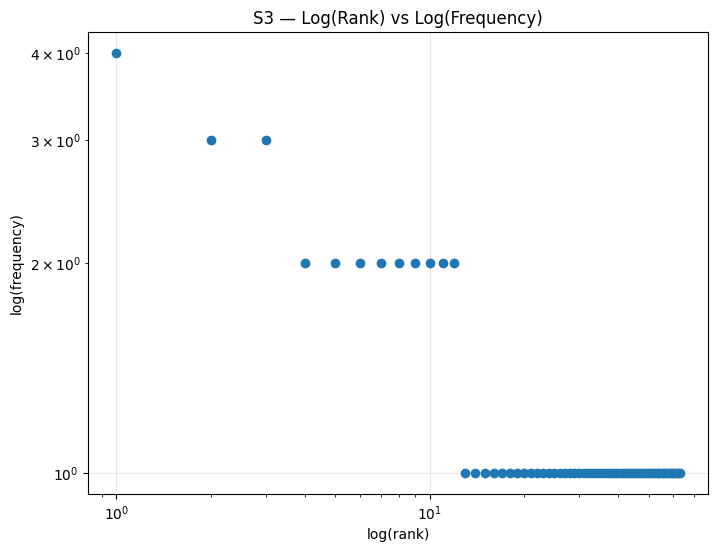


TOP 5 BIGRAMS — S1
1 ('.', 'the') 8
2 ('.', 'i') 6
3 ('.', 'please') 3
4 ('the', 'printer') 2
5 ('the', 'same') 2

TOP 5 BIGRAMS — S3
1 ('problem', 'occurs') 2
2 ('please', 'help') 2
3 ('printer', 'keeps') 1
4 ('keeps', 'asking') 1
5 ('asking', 'login') 1

TTR INTERPRETATION
S1 TTR = 0.5583
S4 TTR = 0.7595

TTR changes from S1 to S4 because the two corpora
contain different types of tokens.

S1 contains all tokens, including punctuation and
stopwords.

S3 removes punctuation and stopwords.

S4 then applies Porter stemming to S3. Stemming
combines related word forms into common stems, which
usually reduces the number of unique types relative
to the number of tokens.

Therefore, the vocabulary diversity measured by TTR
changes between S1 and S4.



In [32]:
# ============================================
# Q5. CORPUS STATISTICS
# ============================================

from collections import Counter
from nltk.util import bigrams
import numpy as np
import matplotlib.pyplot as plt


# ============================================
# S1 — ALL TOKENS
# ============================================

S1 = []

for result in processed.values():

    S1.extend(
        result["tokens"]
    )


# ============================================
# S2 — TOKENS WITHOUT PUNCTUATION
# ============================================

S2 = [
    token
    for token in S1
    if not is_punct(token)
]


# ============================================
# S3 — FINAL TOKENS
# ============================================

S3 = []

for result in processed.values():

    S3.extend(
        result["final"]
    )


# ============================================
# S4 — PORTER STEMMED S3
# ============================================

S4 = [
    porter.stem(token)
    for token in S3
]


# ============================================
# FUNCTION FOR CORPUS STATISTICS
# ============================================

def corpus_statistics(tokens):

    total_tokens = len(tokens)

    unique_tokens = len(
        set(tokens)
    )

    if total_tokens > 0:

        ttr = (
            unique_tokens /
            total_tokens
        )

    else:

        ttr = 0

    return (
        total_tokens,
        unique_tokens,
        ttr
    )


# ============================================
# CREATE TABLE
# ============================================

statistics = []

for name, corpus in [
    ("S1 — All tokens", S1),
    ("S2 — Without punctuation", S2),
    ("S3 — Final tokens", S3),
    ("S4 — Porter stemmed S3", S4)
]:

    total, unique, ttr = corpus_statistics(
        corpus
    )

    statistics.append({

        "Corpus": name,

        "Total Tokens": total,

        "Unique Tokens": unique,

        "TTR": round(ttr, 4)
    })


statistics_df = pd.DataFrame(
    statistics
)


print("="*70)
print("CORPUS STATISTICS")
print("="*70)

display(statistics_df)


# ============================================
# TOP 10 WORDS — S1
# ============================================

print("\n" + "="*70)
print("TOP 10 WORDS — S1")
print("="*70)

top10_S1 = Counter(
    S1
).most_common(10)

for rank, (word, frequency) in enumerate(
    top10_S1,
    1
):

    print(
        rank,
        word,
        frequency
    )


# ============================================
# TOP 10 WORDS — S3
# ============================================

print("\n" + "="*70)
print("TOP 10 WORDS — S3")
print("="*70)

top10_S3 = Counter(
    S3
).most_common(10)

for rank, (word, frequency) in enumerate(
    top10_S3,
    1
):

    print(
        rank,
        word,
        frequency
    )


# ============================================
# ZIPF PLOT
# ============================================

frequency_counts = sorted(
    Counter(S3).values(),
    reverse=True
)

ranks = np.arange(
    1,
    len(frequency_counts) + 1
)


plt.figure(
    figsize=(8, 6)
)

plt.loglog(
    ranks,
    frequency_counts,
    marker="o",
    linestyle="none"
)

plt.xlabel(
    "log(rank)"
)

plt.ylabel(
    "log(frequency)"
)

plt.title(
    "S3 — Log(Rank) vs Log(Frequency)"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================
# TOP 5 BIGRAMS — S1
# ============================================

print("\n" + "="*70)
print("TOP 5 BIGRAMS — S1")
print("="*70)

top5_bigrams_S1 = Counter(
    bigrams(S1)
).most_common(5)

for rank, (bigram, frequency) in enumerate(
    top5_bigrams_S1,
    1
):

    print(
        rank,
        bigram,
        frequency
    )


# ============================================
# TOP 5 BIGRAMS — S3
# ============================================

print("\n" + "="*70)
print("TOP 5 BIGRAMS — S3")
print("="*70)

top5_bigrams_S3 = Counter(
    bigrams(S3)
).most_common(5)

for rank, (bigram, frequency) in enumerate(
    top5_bigrams_S3,
    1
):

    print(
        rank,
        bigram,
        frequency
    )


# ============================================
# TTR INTERPRETATION
# ============================================

s1_ttr = statistics_df.loc[
    statistics_df["Corpus"] == "S1 — All tokens",
    "TTR"
].iloc[0]

s4_ttr = statistics_df.loc[
    statistics_df["Corpus"] == "S4 — Porter stemmed S3",
    "TTR"
].iloc[0]


print("\n" + "="*70)
print("TTR INTERPRETATION")
print("="*70)

print(
    f"S1 TTR = {s1_ttr}"
)

print(
    f"S4 TTR = {s4_ttr}"
)

print("""
TTR changes from S1 to S4 because the two corpora
contain different types of tokens.

S1 contains all tokens, including punctuation and
stopwords.

S3 removes punctuation and stopwords.

S4 then applies Porter stemming to S3. Stemming
combines related word forms into common stems, which
usually reduces the number of unique types relative
to the number of tokens.

Therefore, the vocabulary diversity measured by TTR
changes between S1 and S4.
""")

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*

In [33]:
# ============================================
# Q6. INTERPRETATION
# ============================================

print("="*70)
print("Q6(a) — WHY DOES TTR CHANGE FROM S1 TO S4?")
print("="*70)

print(f"S1 TTR = {s1_ttr}")
print(f"S4 TTR = {s4_ttr}")

print("""
TTR changes because S1 contains all tokens, including
punctuation and stopwords, while S4 contains the final
tokens after punctuation and stopword removal followed
by Porter stemming.

Porter stemming reduces different word forms to common
stems. Therefore, the number of unique tokens changes,
which changes the Type-Token Ratio.
""")


# ============================================
# Q6(b)
# ============================================

print("\n" + "="*70)
print("Q6(b) — word_tokenize() vs CUSTOM TOKENIZER")
print("="*70)

print("""
Example:

word_tokenize("The state-of-the-art lab isn't open.")

can split the structured forms into several tokens,
whereas my_tokenize() keeps:

    state-of-the-art
    isn't

as single tokens.

The difference occurs because the custom RegexpTokenizer
pattern explicitly preserves hyphenated words and
contractions.
""")


# ============================================
# Q6(c)
# ============================================

print("\n" + "="*70)
print("Q6(c) — UNDESIRABLE STEMMING")
print("="*70)

bad_stemming = different_df[
    (
        different_df["Porter"]
        != different_df["Word"]
    )
    &
    (
        different_df["Porter"]
        != different_df["WordNet"]
    )
]

if len(bad_stemming) > 0:

    example = bad_stemming.iloc[0]

    print(
        f"Example: {example['Word']} "
        f"-> {example['Porter']}"
    )

    print("""
This can be undesirable because stemming uses simple
suffix-based rules and can produce a shortened form
that is not a proper English word or loses part of the
original meaning.
""")

else:

    print("""
Inspect the Q4 comparison table for a stemming result
where the produced stem is not an appropriate word.
""")


# ============================================
# Q6(d)
# ============================================

print("\n" + "="*70)
print("Q6(d) — POS-AWARE LEMMATIZATION")
print("="*70)

lemma_examples = different_df[
    (
        different_df["WordNet"]
        != different_df["Word"]
    )
]

if len(lemma_examples) > 0:

    example = lemma_examples.iloc[0]

    print(
        f"Example: {example['Word']} "
        f"({example['POS']}) -> "
        f"{example['WordNet']}"
    )

    print("""
POS-aware lemmatization preserves meaning better because
it uses the grammatical part of speech.

For example, a verb can be converted to its proper
dictionary form rather than simply removing characters
from the end of the word.

Stemming only applies heuristic suffix-removal rules,
whereas WordNet lemmatization uses both the word and
its POS information.
""")

else:

    print(
        "Use the Q4 table to select a POS-aware lemma example."
    )

Q6(a) — WHY DOES TTR CHANGE FROM S1 TO S4?
S1 TTR = 0.5583
S4 TTR = 0.7595

TTR changes because S1 contains all tokens, including
punctuation and stopwords, while S4 contains the final
tokens after punctuation and stopword removal followed
by Porter stemming.

Porter stemming reduces different word forms to common
stems. Therefore, the number of unique tokens changes,
which changes the Type-Token Ratio.


Q6(b) — word_tokenize() vs CUSTOM TOKENIZER

Example:

word_tokenize("The state-of-the-art lab isn't open.")

can split the structured forms into several tokens,
whereas my_tokenize() keeps:

    state-of-the-art
    isn't

as single tokens.

The difference occurs because the custom RegexpTokenizer
pattern explicitly preserves hyphenated words and
contractions.


Q6(c) — UNDESIRABLE STEMMING
Example: another -> anoth

This can be undesirable because stemming uses simple
suffix-based rules and can produce a shortened form
that is not a proper English word or loses part of the
original 